In [1]:
# For convenience, let's begin by enabling
# automatic reloading of modules when they change.
%load_ext autoreload
%autoreload 2

import numpy as np
from collections import OrderedDict
import os
import sys

import warnings
warnings.filterwarnings('ignore')

import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict

from qiskit_metal.toolbox_metal import math_and_overrides

from qiskit_metal.qlibrary.core import QComponent

from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder

from qiskit_metal.qlibrary.qubits.fluxonium_manucharyan import FluxoniumPocket

from qiskit_metal.qlibrary.couplers.line_tee import LineTee

from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven #bonding

from qiskit_metal.qlibrary.terminations.open_to_ground_v2 import OpenToGround

from qiskit_metal.qlibrary.couplers.T import T


import pyEPR as epr
from qiskit_metal.analyses.quantization import EPRanalysis

from scipy.constants import c, e, hbar
from scipy.constants import physical_constants as pc

# Example of use of Manucharyan fluxonium design
This notebook shows how to create a fluxonium qubit with the Manucharyan design using Qiskit Metal.

## Energy functions

These functions calculate the energy of the fluxonium qubit based on its parameters. Please check units before using them.

In [2]:
varphi_0 = pc['mag. flux quantum'][0]/ (2*np.pi) # in Wb

get_EC = lambda C_sigma: e**2 / (2*C_sigma*1e-6 * hbar * 2*np.pi) # in GHz, C_sigma in fF  OK!
get_EJ = lambda I0: I0 * varphi_0 / (2*np.pi*hbar) *1e-18 # I0 in nA and varphi_0 in Wb OK!
get_EL = lambda L: varphi_0**2 / (L*2*np.pi*hbar) # in GHz, L in nH  OK!
get_Cr = lambda f_0, Z0: np.pi / (2 * 2*np.pi*f_0 * Z0)*1e6 # in fF, omega_0 in GHz, Z0 in Ohm  OK!
get_Lr = lambda f_0, Cr: 1 / ((2*np.pi*f_0)**2 * Cr) * 1e6 # in nH, omega_0 in GHz, Cr in fF    OK!
get_g = lambda Cg, C_sigma, Cr, Zr: 2*e * Cg *1e15/ (C_sigma * Cr) * np.sqrt(hbar / (2*Zr)) / (2*np.pi*hbar) * 1e-6 # OK! 

## Chip setup

In [3]:
design = designs.DesignPlanar()
design.chips.main.material = 'silicon'

design.variables['cpw_width'] = '10um' #S from reference 2
design.variables['cpw_gap'] = '6um' #W from reference 2
design._chips['main']['size']['size_x'] = '5mm'
design._chips['main']['size']['size_y'] = '5mm'
design._chips['main']['size']['size_z'] = '-600um' #Our wafer thicknes is 525 um+/-10

# design.chips['main'].size = {'center_x': 0, 'center_y': 0, 'size_x': '0um', 'size_y': '0um'}

# If you disable the next line with "overwrite_enabled", then you will need to
# delete a component [<component>.delete()] before recreating it.
design.overwrite_enabled = True

Gui start

In [4]:
gui = MetalGUI(design)

## Fluxonium pocket

In this section, we create a fluxonium qubit with the Manucharyan design. In this notebook are listed all the parameters that can be modified.

This qubit pocket has also the posibility to add a resonator made by two rounded pads and a Josephson junction array. So in the same pocket we can have the qubit, flux lines and resonator. Then we need a T coupler to couple the resonator to a transmission line.

In [5]:
options = Dict(
        # Position and orientation
        pos_x='2mm', pos_y='1mm', orientation=0, chip='main',
        cpw_width='10um', cpw_gap='6um',

        # Pocket (background)
        back_gap_left = '100um',    # extra left margin
        back_gap_right = '750um',   # extra right margin
        back_gap_top = '55um',     # extra top margin
        back_gap_bottom = '100um',  # extra bottom margin

        # Pads (capacitor)
        pad_width_max='80um',
        pad_width_min='4um',
        pad_height='100um',
        pad_gap='45um',
        # Loop
        loop_position='left',          # define the position of the loop in qubit design (default: right)
        loop_height='18um',             # define the height of the loop (be careful to keep longer the pad_gap)
        loop_width='70um',              # define the width of the loop (metal segment to close the loop)

        # central JJ
        jj_width='5um',                 # width of the JJ
        jj_height='5um',                # height of the JJ
        L_j='40.7885nH',                # inductance of the JJ (used in the EPR simulation)
        C_j='0.72fF',                   # capacitance of the JJ (used in the EPR simulation)

        # JJ arrays loop
        jj_array_width='4um',       # width of the JJ array lines
        L_jj='218.823nH',
        gds_cell_jj_array='gds_cell_jj_array',

        # Coupled resonator
        resonator_options=Dict(
            make_resonator=True,        # flag to make resonator
            resonator_length='100um',   # length of the straight section
            resonator_width='30um',     # width of the resonator
            resonator_gap='16um',       # gap between pads
            qubit_res_gap='40um',       # gap between qubit and resonator
            jj_dist='35um',             # distance from the JJ to the resonator
            jj_array_width='4um',       # width of the JJ array lines
            L_res='48.74nH',              # inductance of the resonator
        ),

        # Flux bias line
        flux_line_options=Dict(
            make_flux_bias_line=True,   # flag to make flux bias line
            total_length='1.5mm',       # total length of the flux line
            width='8um',                # width of the flux line
            sep_lines='5.2um',          # separation between the two lines
            wait_length='100um',        # wait length from loop to rest of the line
            adjust_length='50um',       # length to adjust loop width to flux line width
            pad_width='80um',           # width of the pad at the end of the line
            pad_height='100um',         # height of the pad at the end of the line
            pad_gap='100um',            # gap between the pads
        )
    )

# Create a fluxonium qubit with the Manucharyan design
fluxonium_1 = FluxoniumPocket(design, 'Q1', options=options)


gui.rebuild()
gui.autoscale()

## T Coupler

Here we create a T coupler to couple the resonator of the fluxonium qubit to a transmission line.

In [6]:
t_options = Dict(   pos_x='2.3mm',
                    pos_y='1.468mm',
                    orientation=0,
                    prime_width='400um',
                    prime_length='800um',
                    second_width='10um',
                    second_length='900um',
                    gap='50um')

conector = T(design, 'coupler', options=t_options)

gui.rebuild()
gui.autoscale()

## Lumped port

We add this port to have a path to connect the chip to the outside world. Also this port is useful for EM simulations because it defines where the waveforms will be launched.

In [7]:
ops_lp1 = Dict(chip='main', pos_x='2.3mm', pos_y='2.7mm', orientation='-90', lead_length='10um', 
                pad_width='600um', pad_gap='50um', trace_width='400um', trace_gap='60um')

LP1 = LaunchpadWirebondDriven(design, 'LP1', options = ops_lp1)

gui.rebuild()
gui.autoscale()

## Line to connect

This line connects the T coupler to the lumped port.

In [8]:
## Conecto LP1 con el extremo izquierdo del capacitor
opt_line = Dict(chip='main', trace_width ='400um',
        trace_gap ='50um', fillet='0um', hfss_wire_bonds = True, lead=Dict(end_straight='0.0mm', start_straight='0.0mm'),
        pin_inputs=Dict(start_pin=Dict(component='LP1', pin='tie'),
                        end_pin=Dict(component='coupler', pin='prime_end')
                        )
        )

linea_1 = RoutePathfinder(design, 'linea_1', options = opt_line )

gui.rebuild()
gui.autoscale()

## Capacitance extraction

We can perform a electrostatic simulation to extract the capacitance matrix of the qubit. This allows us to calculate the charging energy of the qubit and other relevant parameters.

In [19]:
from qiskit_metal.analyses.quantization import LOManalysis

c1 = LOManalysis(design, "q3d") # we use this class to perform the LOM analysis, which is a similiar than EPR analysis, but it performs electrostatic simulation to calculate the capacitance and inductance of the design. .
q3d = c1.sim.renderer   # this is the renderer that the class LOManalysis uses to perform the simulation. It is a low level manipulation of the design, so you can use it to perform the simulation without using the class LOManalysis.

In [20]:
# Now we can set the parameters for the simulation
c1.sim.sim_setup_name = "capacitances"
c1.sim.print_run_args()
c1.sim.setup.max_passes = 15
c1.sim.setup_update(solution_order = 'High', auto_increase_solution_order = 'True')

This analysis object run with the following kwargs:
{}



In [21]:
c1.sim.run(components=[], open_terminations=[], name='capacitance') # all the components, all the terminations

INFO 04:38PM [connect_project]: Connecting to Ansys Desktop API...
INFO 04:38PM [load_ansys_project]: 	Opened Ansys App
INFO 04:38PM [load_ansys_project]: 	Opened Ansys Desktop v2024.2.1
INFO 04:38PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Mac/Home/Documents/Ansoft/
	Project:   Project2
INFO 04:38PM [connect_design]: 	Opened active design
	Design:    capacitance_q3d [Solution type: Q3D]
INFO 04:38PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 04:38PM [connect]: 	Connected to project "Project2" and design "capacitance_q3d" 😀 

INFO 04:38PM [connect_design]: 	Opened active design
	Design:    capacitance_q3d [Solution type: Q3D]
INFO 04:38PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 04:38PM [analyze]: Analyzing setup Setup
INFO 04:40PM [get_matrix]: Exporting matrix data to (C:\Users\MAXIMI~1\AppData\Local\Temp\tmp7_m_kug1.txt, C, , Setup:LastAdaptive, "Original", "ohm", "nH", "fF", "mSie", 50000000

In [22]:
cap_matrix = c1.sim.capacitance_matrix # this returns the capacitance matrix as a pandas dataFrame. The important capacitances are the non-diagonal elements. Note that non-diagonal elements are negative, this does not mean that the capacitance is negative, it just a convention of the solver to represent the capacitance matrix. 
# you can se a better explanation in the following link: https://www.fastfieldsolvers.com/Papers/The_Maxwell_Capacitance_Matrix_WP110301_R02.pdf
cap_matrix

,close_loop_Q1,g_wb,launch_pad_LP1,pads_0_Q1,pads_1_Q1,resonator_0_Q1,resonator_1_Q1
close_loop_Q1,154.85891,-139.45592,-3.96855,-2.72616,-2.54956,-1.11826,-0.85923
g_wb,-139.45592,758.44649,-450.54707,-12.12674,-8.28799,-5.70891,-6.38789
launch_pad_LP1,-3.96855,-450.54707,473.92307,-1.55792,-2.43575,-2.50467,-4.09504
pads_0_Q1,-2.72616,-12.12674,-1.55792,20.17395,-2.58506,-0.45566,-0.31597
pads_1_Q1,-2.54956,-8.28799,-2.43575,-2.58506,20.95950,-3.57692,-1.18439
resonator_0_Q1,-1.11826,-5.70891,-2.50467,-0.45566,-3.57692,19.90162,-6.32833
resonator_1_Q1,-0.85923,-6.38789,-4.09504,-0.31597,-1.18439,-6.32833,19.36763


Get the energy

In [ ]:
C = abs(cap_matrix['pads_0_Q1']['pads_1_Q1'])
Cr = abs(cap_matrix['resonator_0_Q1']['resonator_0_Q1'])
Ec = get_EC(C)

get_Lr_from_f0_Cr = lambda f_0, Cr: 1 / ((2*np.pi*f_0)**2 * Cr) * 1e6 # in nH, omega_0 in GHz, Cr in fF    OK!
f0 = 5.11 # GHz

Lr = get_Lr_from_f0_Cr(f0, Cr)
N_junctions = 8
L0 = Lr/N_junctions

# get_I0_from_L = lambda L: varphi_0 / L*1e-9
# L0 = lambda I_c: varphi_0/I_c*1e18
get_I0_from_L = lambda L: varphi_0 / L *1e18# in nA, L in nH
I0 = get_I0_from_L(L0)

EJ = get_EJ(I0)

print('C = %.2f fF' % C)
print('Cr = %.2f fF' % Cr)
print('Ec = %.2f GHz' % Ec)
print(f'For a f0 = {f0} GHz and N_junctions = {N_junctions}:')
print('\tLr = %.2f nH' % Lr)
print(f'\tInductance per junction: {Lr/N_junctions:.2f} nH')
print('\tI0 = %f nA' % I0)
print('\tEJ per junction= %.2f GHz' % EJ)

C = 2.59 fF
Cr = 19.90 fF
Ec = 7.49 GHz
For a f0 = 5.11 GHz and N_junctions = 8:
	Lr = 48.74 nH
	Inductance per junction: 6.09 nH
	I0 = 54.015167 nA
	EJ per junction= 26.83 GHz


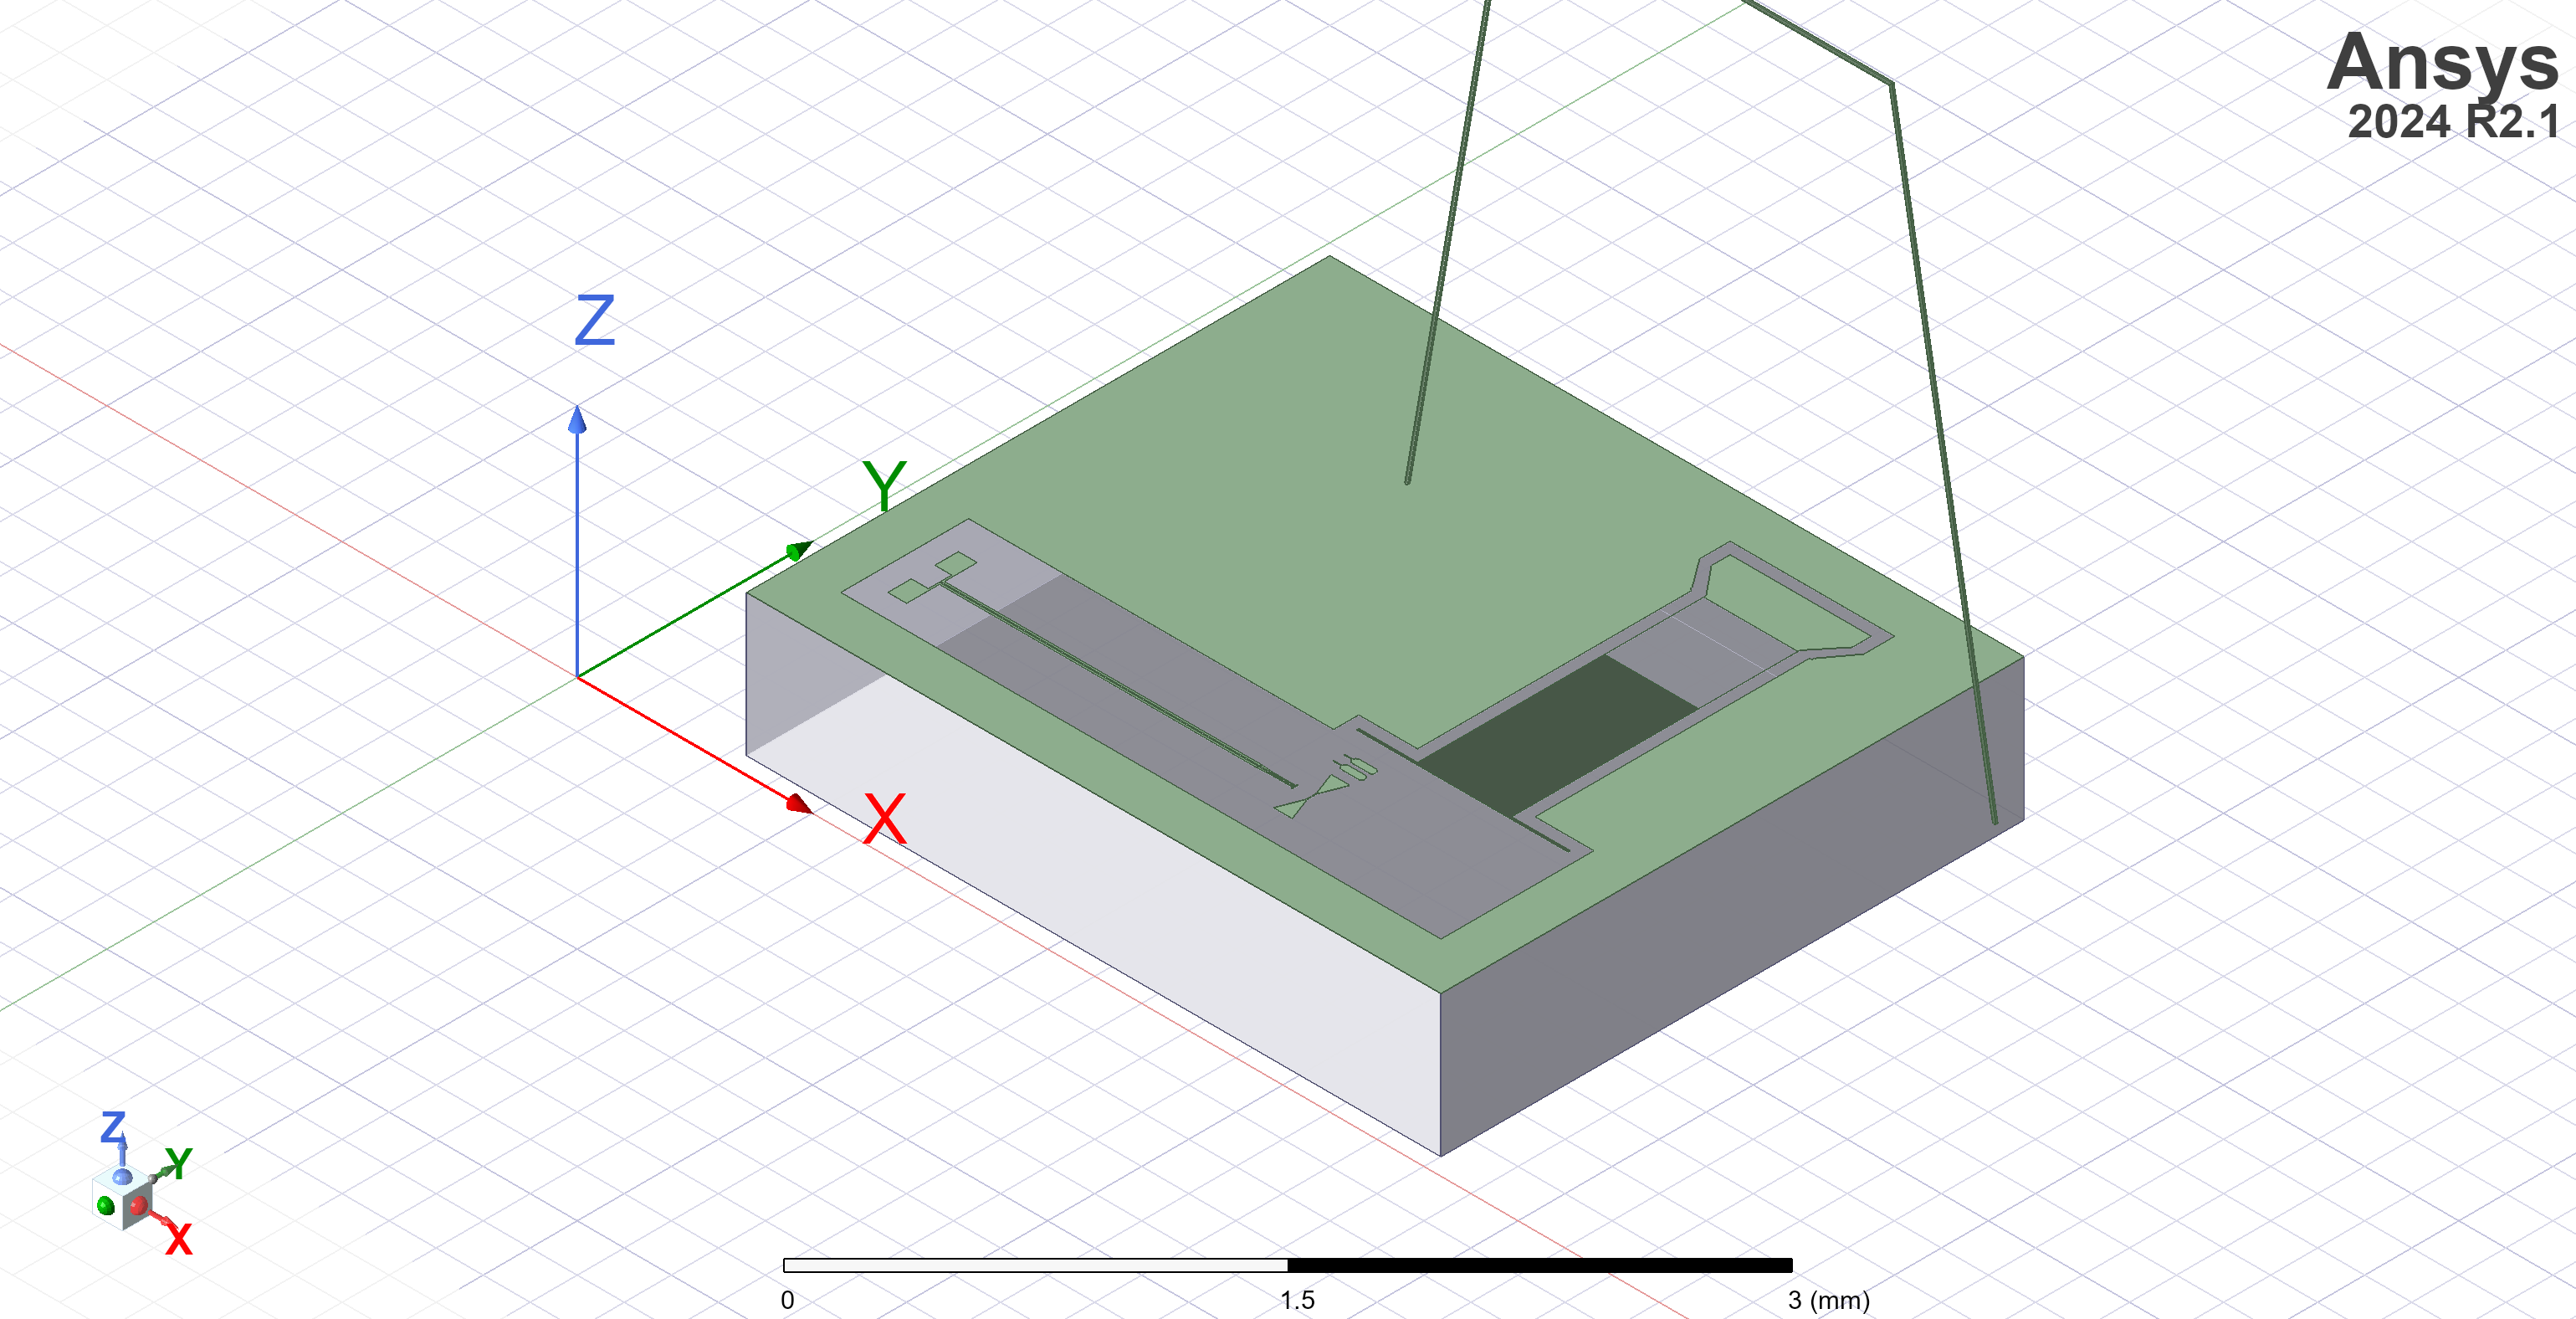

WindowsPath('y:/Tesis/src/libraries/qiskit_metal/Fluxonium Design Examples/manucharyan design/ansys.png')

In [45]:
q3d.save_screenshot()

In [48]:
q3d.close() # close the q3d application

True

## Eigenmode (EPR simulations)

In [50]:
from qiskit_metal.analyses.quantization import EPRanalysis
eig_res = EPRanalysis(design, "hfss")
hfss_render = eig_res.sim.renderer    # that's the real render which perfom the link with ansys. We can use it, but it's like a low level manipulation of the design.

In [53]:
# This function is more easy to use than previous one, because it automatically creates the setup and analyze it.
# with this function you can change the parameters of the setup, like the number of modes, the maximum frequency, etc.
eig_res.sim.setup_update(n_modes = 2,
                        max_delta_f = 0.1,
                        min_freq_ghz = 1,
                        max_passes = 18)

# Now we can run the simulation. This will calculate the eigenmodes of the design and return the results. You have to specify the components that you want to simulate and the open terminals. If you don't specify the open terminals, it will be rendered connected to ground.
eig_res.sim.run(name="ResonatorEPR Fluxonium", components=['Q1'], 
               open_terminations=[], box_plus_buffer = True)
# The function add automatically _hfss to the name of the simulation, so you can use the same name for multiple simulations without problems.

INFO 05:29PM [connect_design]: 	Opened active design
	Design:    ResonatorEPR Fluxonium_hfss [Solution type: Eigenmode]
INFO 05:30PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 05:30PM [analyze]: Analyzing setup Setup
05:47PM 01s INFO [get_f_convergence]: Saved convergences to y:\Tesis\src\libraries\qiskit_metal\Fluxonium Design Examples\manucharyan design\hfss_eig_f_convergence.csv


In [55]:
freqs = eig_res.get_frequencies()
freqs

Design "ResonatorEPR Fluxonium_hfss" info:
	# eigenmodes    2
	# variations    1
Design "ResonatorEPR Fluxonium_hfss" info:
	# eigenmodes    2
	# variations    1


Freq. (GHz)  Quality Factor
variation mode                             
0         0        2.694524             inf
          1        6.094231             inf

INFO 05:57PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


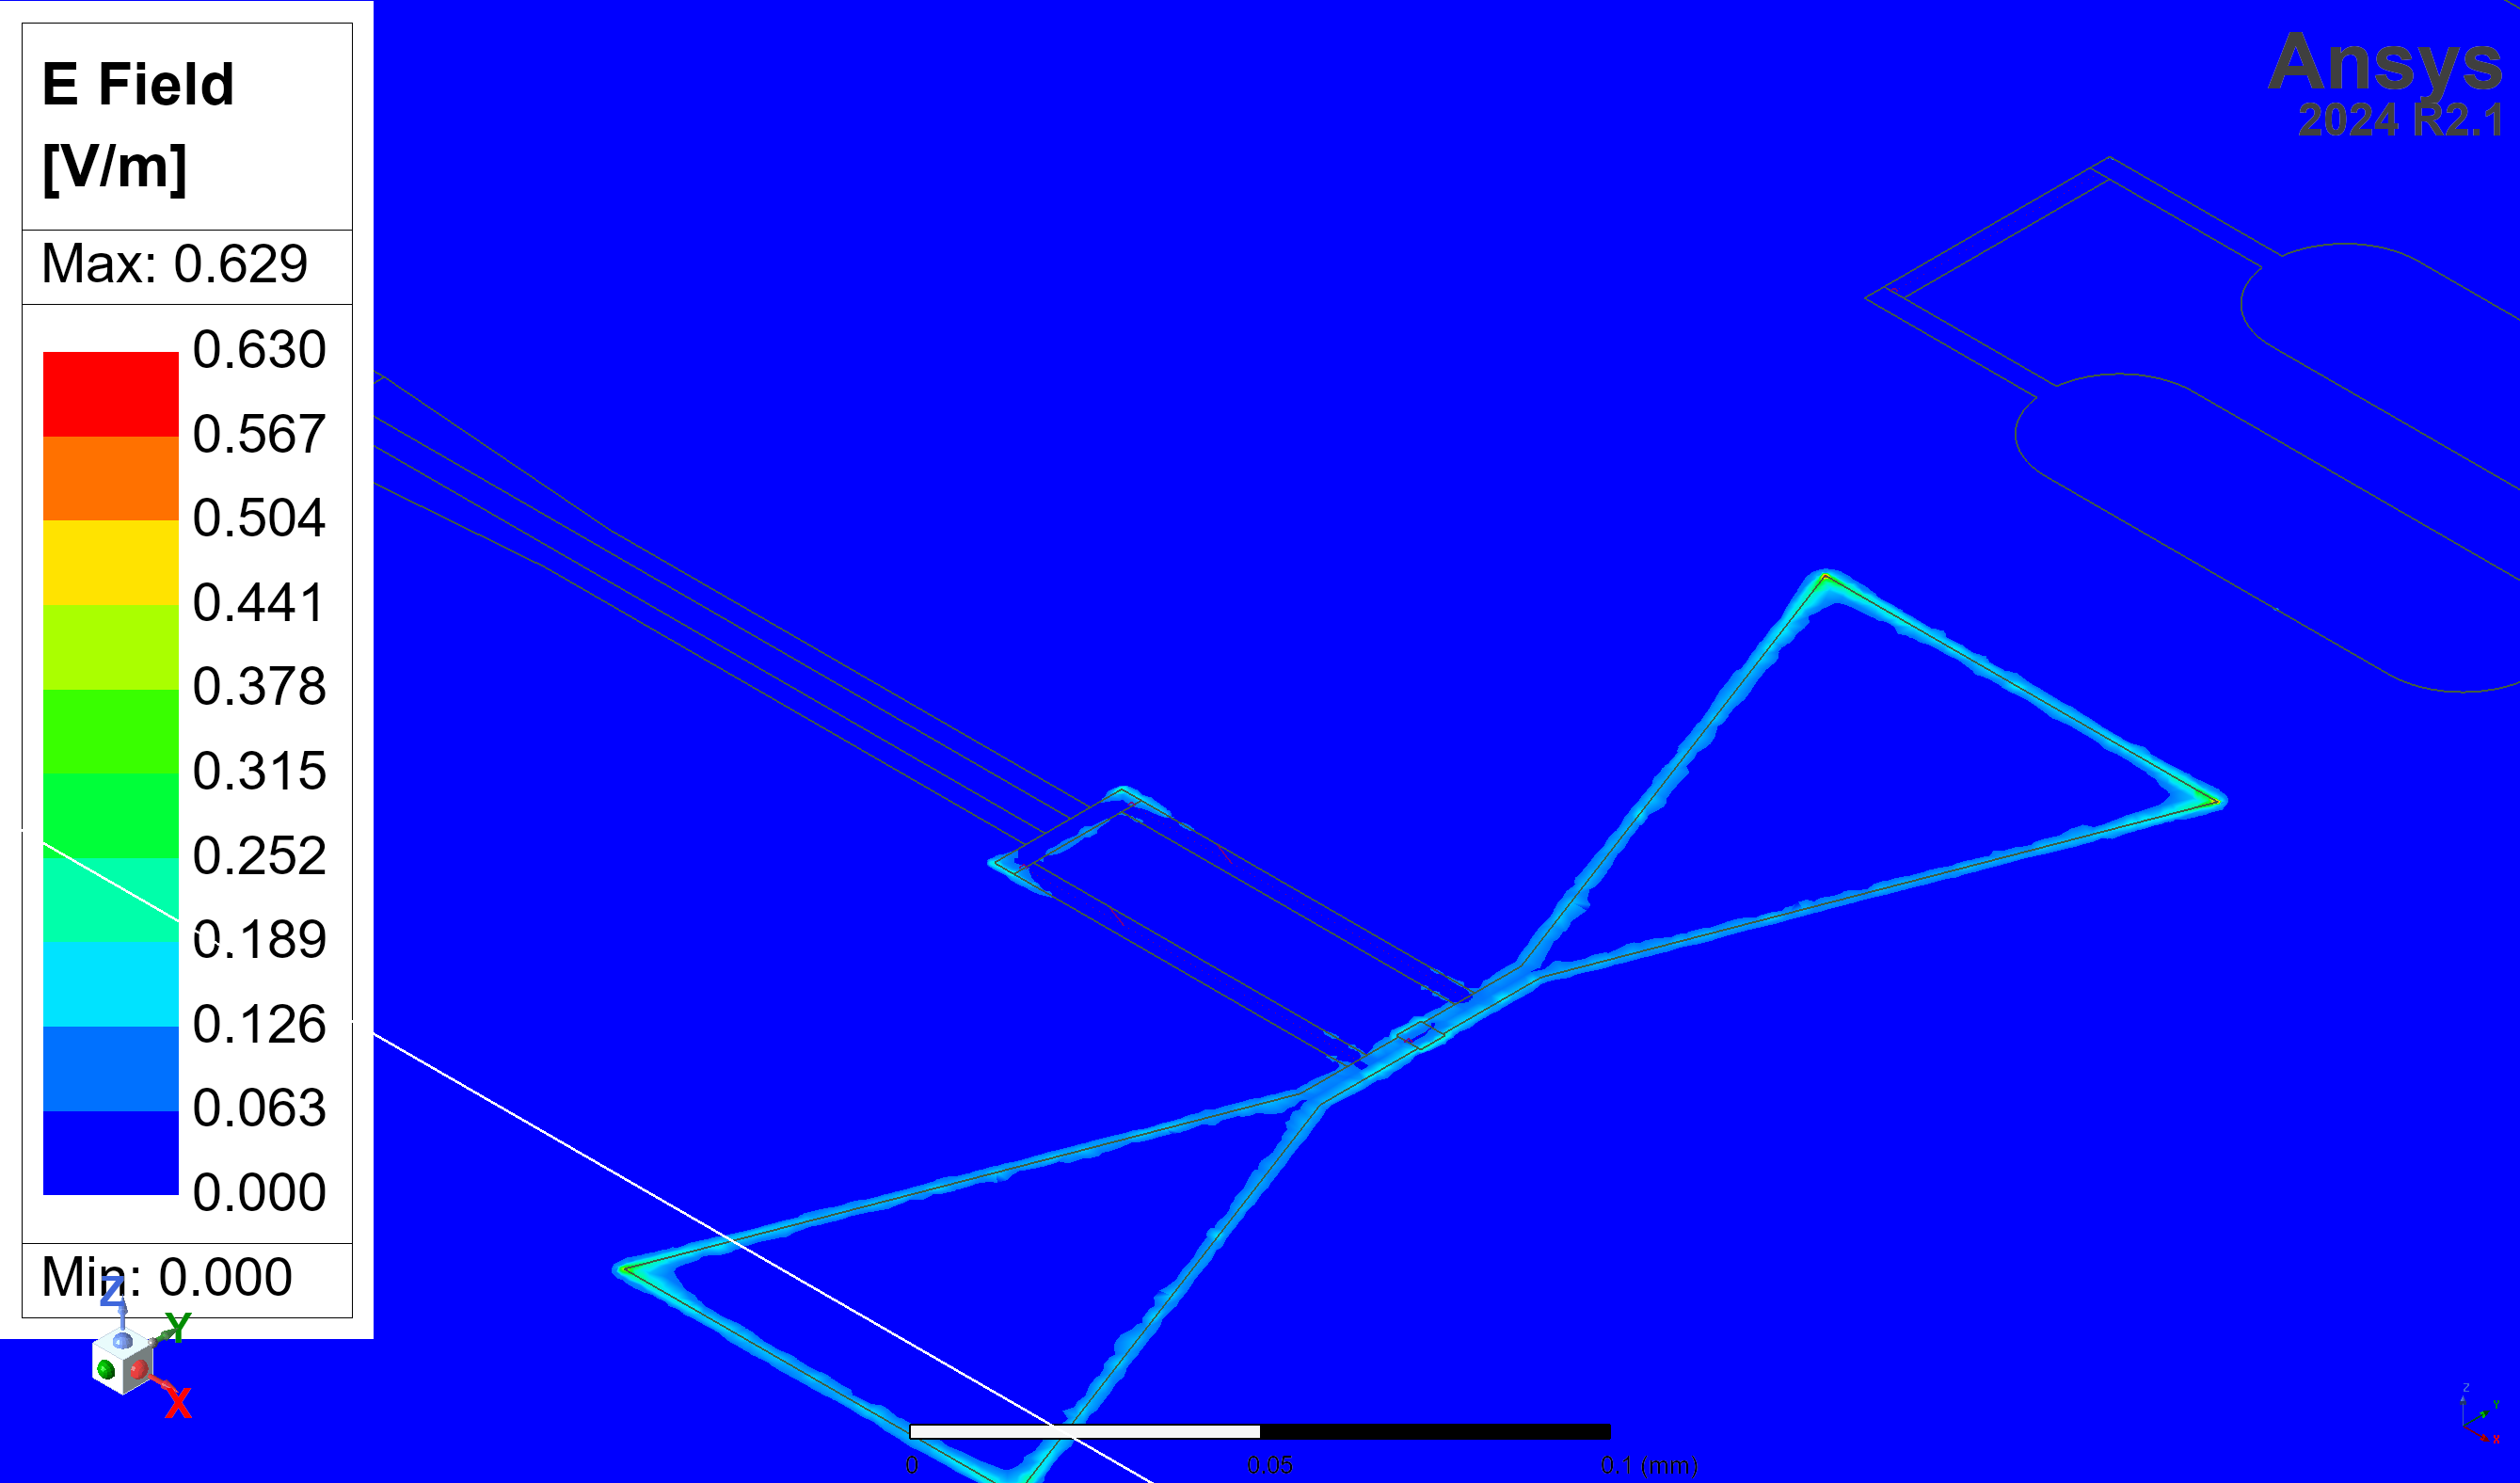

WindowsPath('y:/Tesis/src/libraries/qiskit_metal/Fluxonium Design Examples/manucharyan design/ansys.png')

In [59]:
hfss_render.set_mode(1, 'Setup')
hfss_render.modeler._modeler.ShowWindow()
hfss_render.plot_fields('main')
hfss_render.save_screenshot()

INFO 05:56PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


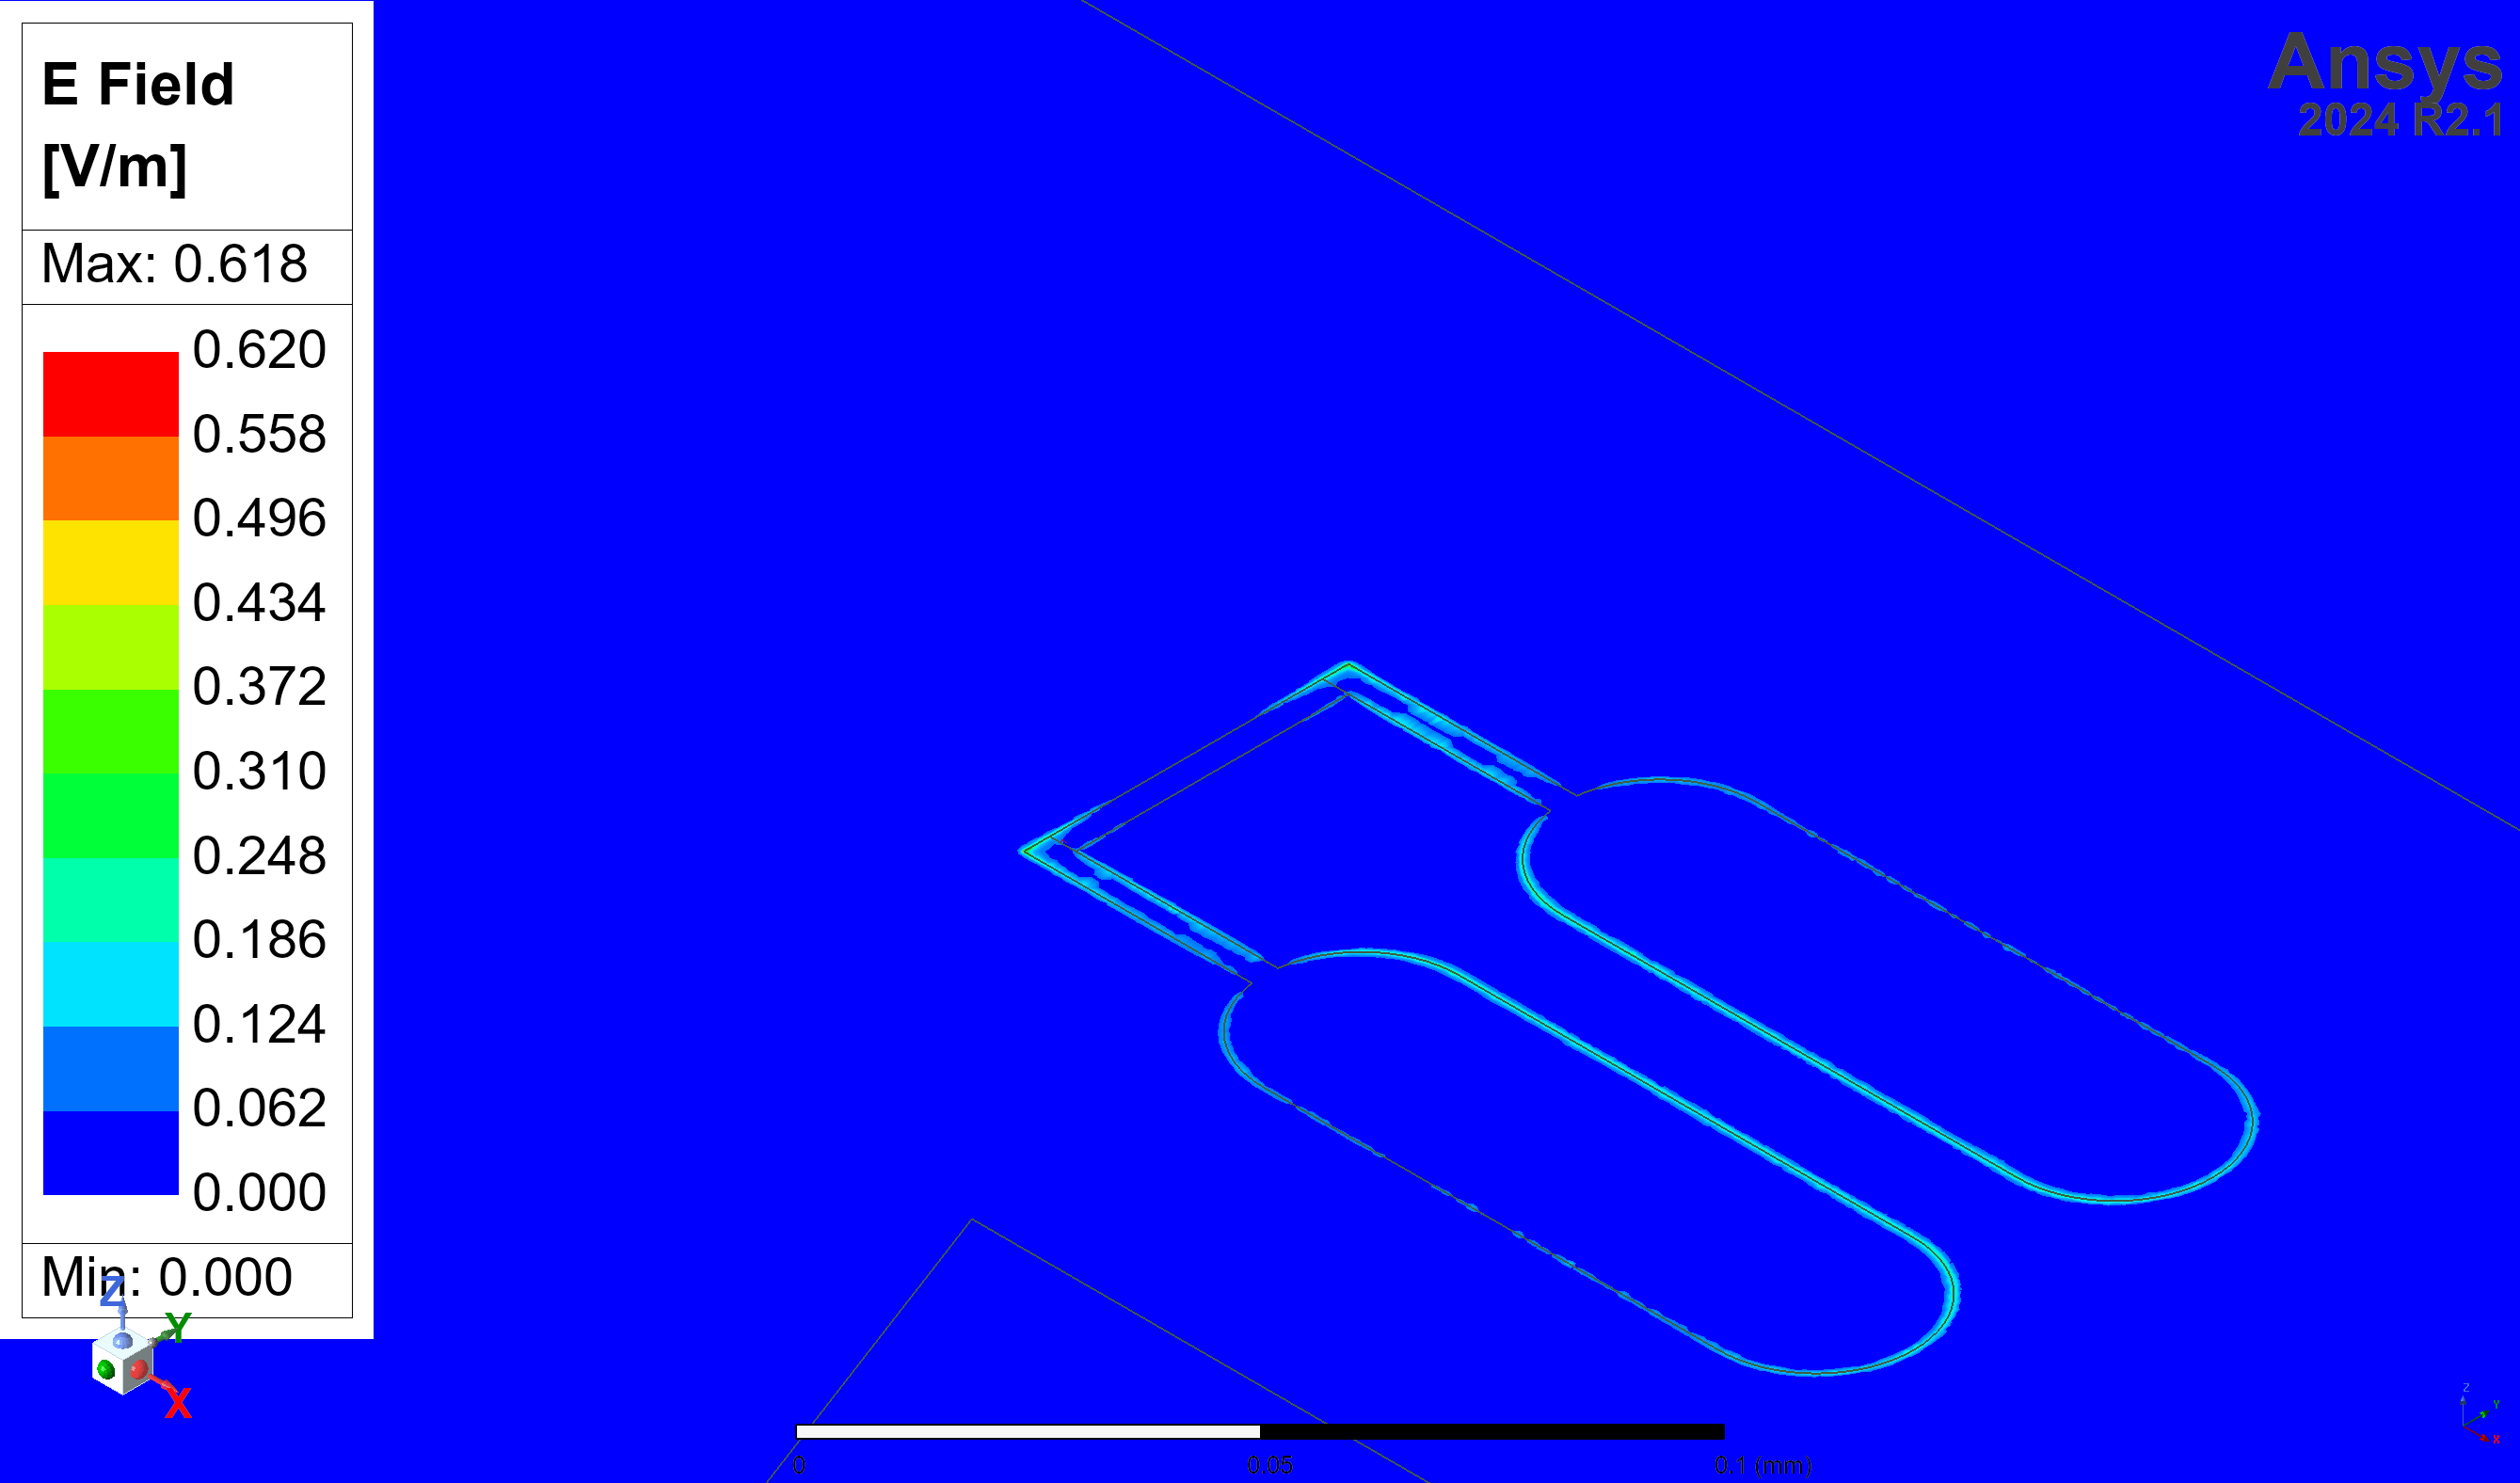

WindowsPath('y:/Tesis/src/libraries/qiskit_metal/Fluxonium Design Examples/manucharyan design/ansys.png')

In [58]:
hfss_render.set_mode(2, 'Setup')
hfss_render.modeler._modeler.ShowWindow()
hfss_render.plot_fields('main')
hfss_render.save_screenshot()

In [60]:
hfss_render.close()

True

## Impedance Scattering

with this module, we can obtain the scattering matrix and the impedance matrix of the design. In this case, we can inject a sweep of frequencies in a lumped port and see the resonance frequency of the resonator.

In [ ]:
# BUG: We can't connect to this due the latest version of Ansys. We need to modify the function add_sweep in the file ansys_renderer.py

In [23]:
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
em1 = ScatteringImpedanceSim(design, "hfss")

In [24]:
em1.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 5,
 'max_delta_s': 0.1,
 'max_passes': 10,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'},
 'sweep_setup': {'name': 'Sweep',
  'start_ghz': 2.0,
  'stop_ghz': 8.0,
  'count': 101,
  'step_ghz': None,
  'type': 'Fast',
  'save_fields': False}}

In [25]:
# example: update single setting
em1.setup.max_passes = 12
# em1.setup.sweep_setup.name = "sweep_1"
em1.setup.sweep_setup.start_ghz = 2
em1.setup.sweep_setup.stop_ghz = 8
# example: update multiple settings
em1.setup_update(max_delta_s = 0.15, freq_ghz = 5.2)

em1.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 5.2,
 'max_delta_s': 0.15,
 'max_passes': 12,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'},
 'sweep_setup': {'name': 'Sweep',
  'start_ghz': 2,
  'stop_ghz': 8,
  'count': 101,
  'step_ghz': None,
  'type': 'Fast',
  'save_fields': False}}

In [29]:
em1.run(name="Scattering", components=[], open_terminations=[], port_list=[('LP1', 'in', 50)],
           jj_to_port=[], box_plus_buffer = True)

INFO 07:06PM [connect_design]: 	Opened active design
	Design:    Scattering_hfss [Solution type: HFSS Hybrid Modal Network]
07:06PM 49s WARNING [activate_ansys_design]: The design_name=Scattering_hfss already exists, but it has solution_type==hfss hybrid modal network, which is different from the requested==drivenmodal. If you want a design with solution type==drivenmodal, please change the name requested for your design to one that does not exist. Alternatively, manually modify the solution_type for design Scattering_hfss from the Ansys GUI.


Adding drivenmodal setup
Solution type: hfss hybrid modal network


ERROR 07:07PM [get_setup]: Could not retrieve setup: Setup
                         Did you give the right name? Does it exist?


AttributeError: 'NoneType' object has no attribute 'name'

In [30]:
design_name= "Sweep_DrivenModal"
qcomp_render = [] # Means to render everything in qgeometry table.
open_terminations = []

# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [('LP1', 'in', 50)]
box_plus_buffer = True

In [32]:
hfss = em1.renderer
hfss.start()

INFO 07:09PM [connect_project]: Connecting to Ansys Desktop API...
INFO 07:09PM [load_ansys_project]: 	Opened Ansys App
INFO 07:09PM [load_ansys_project]: 	Opened Ansys Desktop v2024.2.1
INFO 07:09PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Mac/Home/Documents/Ansoft/
	Project:   Project2
INFO 07:09PM [connect_design]: 	Opened active design
	Design:    Scattering_hfss [Solution type: HFSS Hybrid Modal Network]
ERROR 07:09PM [get_setup]: Could not retrieve setup: Setup
                         Did you give the right name? Does it exist?
ERROR 07:09PM [connect_setup]: Original error 😭: 'NoneType' object has no attribute 'name'



Exception:  Did you provide the correct setup name?                            Failed to pull up setup. 😭

In [33]:
ansys_design = hfss.new_ansys_design("driven modal fluxonium", 'drivenmodal')

Adding drivenmodal design
Solution type: drivenmodal


INFO 07:09PM [connect_design]: 	Opened active design
	Design:    driven modal fluxonium [Solution type: HFSS Hybrid Modal Network]
WARNING 07:09PM [connect_setup]: 	No design setup detected.
ERROR 07:09PM [connect_setup]: Original error 😭: 'NoneType' object has no attribute 'name'



Exception:  Did you provide the correct setup name?                            Failed to pull up setup. 😭

In [34]:
hfss.activate_ansys_design("driven modal fluxonium", 'hfss hybrid modal network')  # use new_ansys_design() to force creation of a blank design

INFO 07:10PM [connect_design]: 	Opened active design
	Design:    driven modal fluxonium [Solution type: HFSS Hybrid Modal Network]


In [35]:
# render the design
hfss.render_design( 
                   open_pins=open_terminations, 
                   port_list=port_list, 
                   box_plus_buffer = box_plus_buffer)

In [36]:
# Set up the driven modal setup with the desired parameters.
setup_args = Dict(
    name="Setup1",
    freq_ghz=5.0,               # Frecuencia central (GHz)
    sweep_start_ghz=4,        # Inicio del barrido
    sweep_stop_ghz=8,        # Fin del barrido
    max_delta_s=0.01,           # Criterio de convergencia (S-parameters)
    max_passes=15               # Número de pasadas
)

print(type(hfss))
# New version of ansys does not has a 'drivenmodal' because was replaced by 'hybrid modal network'. So we configure the setup up manually.
hfss_design = hfss.pinfo.design
print(type(hfss_design))

# Look for existing setups (to clean)
setup_names = hfss_design.get_setup_names()
print(setup_names)

# Delete existing setups (to make sure what we create is the only one)
for name in setup_names:
    hfss_design.delete_setup(name)

# Create a new setup with the specified parameters 
setup = hfss_design.create_dm_setup(name='Setup1')
print(type(setup))
# You can have multiples setups, but need one object for each one to control them. For example if you want to know the setups that you have:
print(f"Setup name: {hfss_design.get_setup_names()}")

# Now we can add a sweep to the setup. WARNING: The names of the sweeps must not include spaces or special characters, otherwise it will not work.
sweep = setup.insert_sweep(4, 8, 4001, name='Sweep')    # 3 to 6 GHz, 4001 points because we dont know where is (you can perform and EPR first). It returns a Sweep object.
print(type(sweep))

<class 'qiskit_metal.renderers.renderer_ansys.hfss_renderer.QHFSSRenderer'>
<class 'pyEPR.ansys.HfssDesign'>
()
<class 'pyEPR.ansys.HfssDMSetup'>
Setup name: ('Setup1',)
<class 'pyEPR.ansys.HfssFrequencySweep'>


In [38]:
# Also you can have multiples sweep for the setup, so you can control them with the object sweep. For example if you want to analyse the sweep that you have
sweep.analyze_sweep()

INFO 07:12PM [analyze]: Analyzing setup Setup1 : Sweep


com_error: (-2147352567, 'Exception occurred.', (0, None, None, None, 0, -2147024349), None)